In [1]:
!pip install rasterio --quiet
!pip install tensorflow --upgrade --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
import numpy as np
import rasterio
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Paths
GLOF_DIR = '/content/drive/MyDrive/GLOF'
NO_GLOF_DIR = '/content/drive/MyDrive/NO_GLOF'

# Image size and band settings
IMG_HEIGHT = 128
IMG_WIDTH = 128
NUM_BANDS = 6
BATCH_SIZE = 16
EPOCHS = 5


In [24]:
import rasterio
import numpy as np

def load_multiband_image(path):
    with rasterio.open(path) as src:
        img = src.read()  # shape: (bands, height, width)
    img = np.transpose(img, (1, 2, 0))  # to shape (height, width, bands)
    img = img.astype(np.float32) / 255.0  # normalize
    return img

def load_dataset():
    images, labels = [], []

    # GLOF = 1
    for filename in os.listdir(GLOF_DIR):
        if filename.endswith('.tif'):
            img = load_multiband_image(os.path.join(GLOF_DIR, filename))
            img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
            images.append(img)
            labels.append(1)

    # NO_GLOF = 0
    no_glof_images = []
    for filename in os.listdir(NO_GLOF_DIR):
        if filename.endswith('.tif'):
            img = load_multiband_image(os.path.join(NO_GLOF_DIR, filename))
            img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
            no_glof_images.append(img)

        # Add original NO_GLOF images
    for img in no_glof_images:
        images.append(img)
        labels.append(0)

    # Augment all of NO_GLOF images
    num_to_augment = int(1.5 * len(no_glof_images))  # ← doubled
    for i in range(num_to_augment):
        img = no_glof_images[i % len(no_glof_images)]  # loop through dataset

        # Apply light augmentation
        aug_img = tf.image.random_flip_left_right(img)
        aug_img = tf.image.random_flip_up_down(aug_img)
        aug_img = tf.image.random_brightness(aug_img, max_delta=0.1)
        aug_img = tf.image.rot90(aug_img, k=np.random.randint(1, 4))

        images.append(aug_img)
        labels.append(0)


    return np.array(images), np.array(labels)


In [25]:
X, y = load_dataset()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [26]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, NUM_BANDS)),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')  # Output is probability
    ])
    return model


In [27]:
# Detect and connect to TPU
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
except:
    strategy = tf.distribute.get_strategy()  # fallback to default strategy

with strategy.scope():
    model = build_model()
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)


Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 392ms/step - accuracy: 0.6448 - loss: 14.2930 - val_accuracy: 0.8276 - val_loss: 0.3846
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 368ms/step - accuracy: 0.9040 - loss: 0.2581 - val_accuracy: 0.7126 - val_loss: 0.7085
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 369ms/step - accuracy: 0.9506 - loss: 0.1189 - val_accuracy: 0.8966 - val_loss: 0.2522
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 364ms/step - accuracy: 0.9955 - loss: 0.0308 - val_accuracy: 0.9195 - val_loss: 0.2873
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 360ms/step - accuracy: 0.9945 - loss: 0.0200 - val_accuracy: 0.9195 - val_loss: 0.3310


In [28]:
predictions = model.predict(test_ds)
for i, prob in enumerate(predictions[:10]):
    print(f"Image {i+1}: Probability of GLOF = {prob[0]*100:.2f}%")


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Image 1: Probability of GLOF = 3.11%
Image 2: Probability of GLOF = 0.00%
Image 3: Probability of GLOF = 0.30%
Image 4: Probability of GLOF = 99.45%
Image 5: Probability of GLOF = 0.00%
Image 6: Probability of GLOF = 0.00%
Image 7: Probability of GLOF = 99.89%
Image 8: Probability of GLOF = 99.98%
Image 9: Probability of GLOF = 0.30%
Image 10: Probability of GLOF = 0.00%


In [29]:
# Get predicted labels (0 or 1)
predicted_labels = (predictions > 0.5).astype(int)

# Get true labels from the test dataset
true_labels = []
for _, label in test_ds.unbatch():
    true_labels.append(int(label.numpy()))
true_labels = np.array(true_labels)

# Compare predictions with true labels
correct_predictions = (predicted_labels.flatten() == true_labels)
accuracy = np.mean(correct_predictions)

# Print comparison for first 10 images
for i in range(10):
    prob = predictions[i][0]
    pred_label = predicted_labels[i][0]
    true_label = true_labels[i]
    correct = "✅" if pred_label == true_label else "❌"
    print(f"Image {i+1}: Predicted = {pred_label} ({prob*100:.2f}%), Actual = {true_label} → {correct}")

print(f"\nOverall Test Accuracy: {accuracy*100:.2f}%")


Image 1: Predicted = 0 (3.11%), Actual = 0 → ✅
Image 2: Predicted = 0 (0.00%), Actual = 0 → ✅
Image 3: Predicted = 0 (0.30%), Actual = 0 → ✅
Image 4: Predicted = 1 (99.45%), Actual = 1 → ✅
Image 5: Predicted = 0 (0.00%), Actual = 0 → ✅
Image 6: Predicted = 0 (0.00%), Actual = 0 → ✅
Image 7: Predicted = 1 (99.89%), Actual = 1 → ✅
Image 8: Predicted = 1 (99.98%), Actual = 1 → ✅
Image 9: Predicted = 0 (0.30%), Actual = 0 → ✅
Image 10: Predicted = 0 (0.00%), Actual = 0 → ✅

Overall Test Accuracy: 96.55%


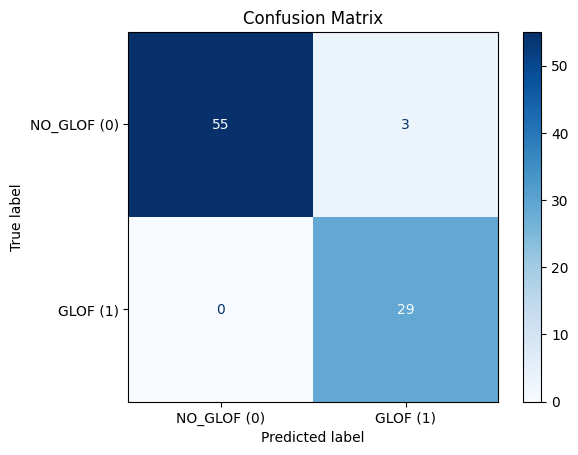

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step 1: Get true labels from test_ds
true_labels = []
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

# Step 2: Convert predicted probabilities to class labels
predicted_labels = [1 if prob[0] > 0.5 else 0 for prob in predictions]

# Step 3: Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Step 4: Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO_GLOF (0)', 'GLOF (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [31]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(true_labels, predicted_labels, target_names=['NO_GLOF (0)', 'GLOF (1)'])

print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

 NO_GLOF (0)       1.00      0.95      0.97        58
    GLOF (1)       0.91      1.00      0.95        29

    accuracy                           0.97        87
   macro avg       0.95      0.97      0.96        87
weighted avg       0.97      0.97      0.97        87



In [32]:
import os
import numpy as np
import tensorflow as tf
import rasterio

# ===== Step 1: Path to the folder containing the 2 real GLOF images =====
image_folder = "/content/drive/MyDrive/test"

# ===== Step 2: Load and preprocess a single multiband .tif image =====
def load_multiband_image(path, target_size=(128, 128)):
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)  # shape: (bands, H, W)
    img = np.transpose(img, (1, 2, 0))  # shape: (H, W, bands)
    img = tf.image.resize(img, target_size)
    img = img / 255.0  # normalize
    return img

# ===== Step 3: Load all .tif images in the folder =====
image_paths = [os.path.join(image_folder, fname)
               for fname in os.listdir(image_folder)
               if fname.endswith(".tif")]

images = [load_multiband_image(p) for p in image_paths]
images_array = tf.stack(images)  # shape: (num_images, 128, 128, 6)

# ===== Step 4: Predict using the trained model =====
predictions = model.predict(images_array)

# ===== Step 5: Print the prediction probabilities =====
for i, (path, prob) in enumerate(zip(image_paths, predictions)):
    image_name = os.path.basename(path)
    print(f"{image_name}: Probability of GLOF = {prob[0]*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
2020-05-25.tif: Probability of GLOF = 77.58%


In [33]:
model.save('/content/drive/MyDrive/CHILL.keras')


In [34]:
model.export('/content/drive/MyDrive/CHILL')  # for TensorFlow Serving or TFLite


Saved artifact at '/content/drive/MyDrive/CHILL'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 6), dtype=tf.float32, name='keras_tensor_24')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138472515481680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138472515481872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138472515481104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138472515485136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138472515480144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138472515483984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138472515484176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138472515473424: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [35]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,120,357 (42.42 MB)

 Trainable params: 3,706,785 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,413,572 (28.28 MB)

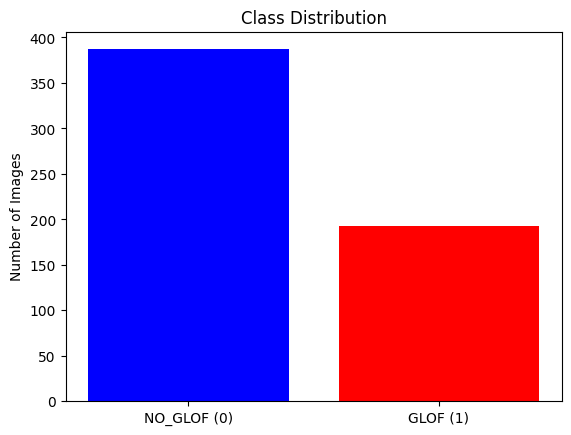

In [36]:
import matplotlib.pyplot as plt

unique, counts = np.unique(y, return_counts=True)
plt.bar(['NO_GLOF (0)', 'GLOF (1)'], counts, color=['blue', 'red'])
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()


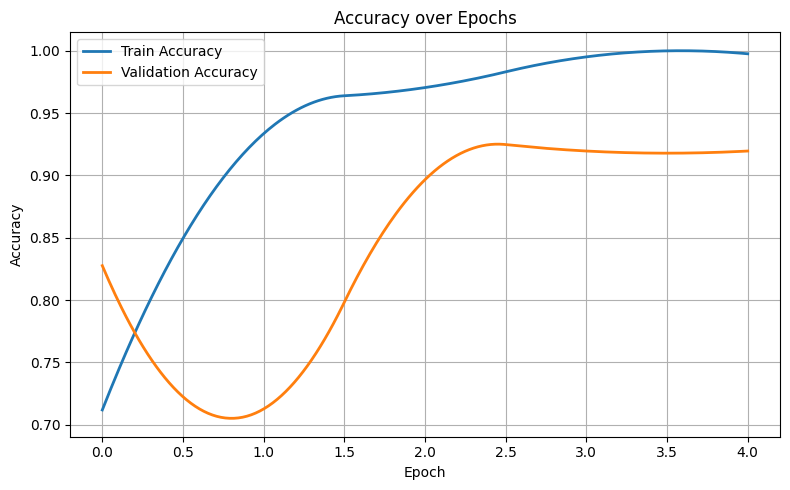

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

def smooth_curve(x, y):
    x_new = np.linspace(x.min(), x.max(), 300)
    spl = make_interp_spline(x, y, k=2)
    y_smooth = spl(x_new)
    return x_new, y_smooth

# Original data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = np.arange(len(acc))

# Smooth
epochs_smooth, acc_smooth = smooth_curve(epochs, np.array(acc))
_, val_acc_smooth = smooth_curve(epochs, np.array(val_acc))

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs_smooth, acc_smooth, label='Train Accuracy', linewidth=2)
plt.plot(epochs_smooth, val_acc_smooth, label='Validation Accuracy', linewidth=2)
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


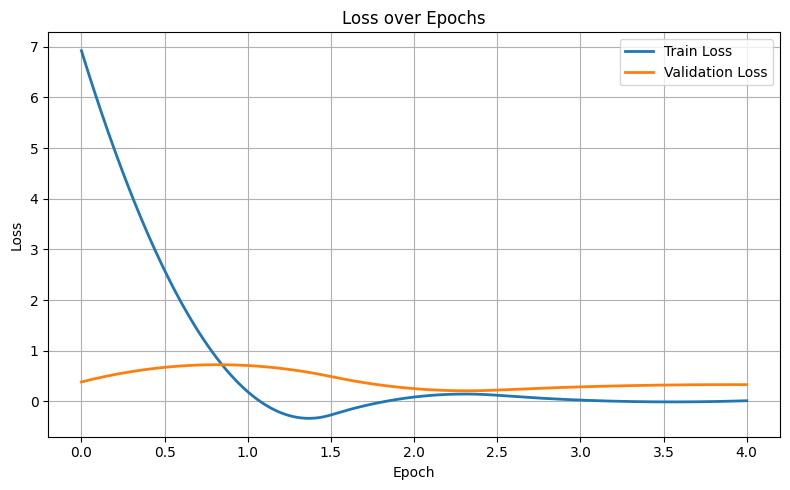

In [38]:
# Original data
loss = history.history['loss']
val_loss = history.history['val_loss']

# Smooth
_, loss_smooth = smooth_curve(epochs, np.array(loss))
_, val_loss_smooth = smooth_curve(epochs, np.array(val_loss))

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs_smooth, loss_smooth, label='Train Loss', linewidth=2)
plt.plot(epochs_smooth, val_loss_smooth, label='Validation Loss', linewidth=2)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
